In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from config import MODELS_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

## Load Data And Tuned Model

In [3]:
pokemon_features = pd.read_parquet(PROCESSED_DATA_DIR / "pokemon_data_features.parquet")
pokemon_raw = pd.read_csv(RAW_DATA_DIR / "pokedex.csv")

In [4]:
y = pokemon_features["total_points"]
X = pokemon_features.drop(columns=["total_points"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

metadata_cols = ["name", "status", "type_1", "type_2", "generation", "height_m", "weight_kg"]
metadata_test = pokemon_raw.loc[X_test.index, metadata_cols].copy()

In [5]:
model = joblib.load(MODELS_DIR / "xg_boost_tuned.joblib")

## Tuned Model Test Performance

In [6]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Tuned XGBoost RMSE: {rmse:.2f}")
print(f"Tuned XGBoost MAE: {mae:.2f}")
print(f"Tuned XGBoost R^2: {r2:.3f}")

Tuned XGBoost RMSE: 58.95
Tuned XGBoost MAE: 42.31
Tuned XGBoost R^2: 0.773


## Tuned Model Prediction Table

In [7]:
results = metadata_test.copy()
results["true_total_points"] = y_test.values
results["pred_total_points"] = y_pred
results["residual"] = results["true_total_points"] - results["pred_total_points"]
results["abs_error"] = results["residual"].abs()
results.head()

,name,status,type_1,type_2,generation,height_m,weight_kg,true_total_points,pred_total_points,residual,abs_error
773,Diggersby,Normal,Normal,Ground,6,1.0,42.4,423,429.591248,-6.591248,6.591248
280,Houndoom,Normal,Dark,Fire,2,1.4,35.0,500,462.075714,37.924286,37.924286
629,Mega Audino,Normal,Normal,Fairy,5,1.5,32.0,545,597.706543,-52.706543,52.706543
318,Mightyena,Normal,Dark,NaN,3,1.0,37.0,420,420.212524,-0.212524,0.212524
1008,Pincurchin,Normal,Electric,NaN,8,0.3,1.0,435,333.794434,101.205566,101.205566


## Tuned Model Prediction Diagnostics

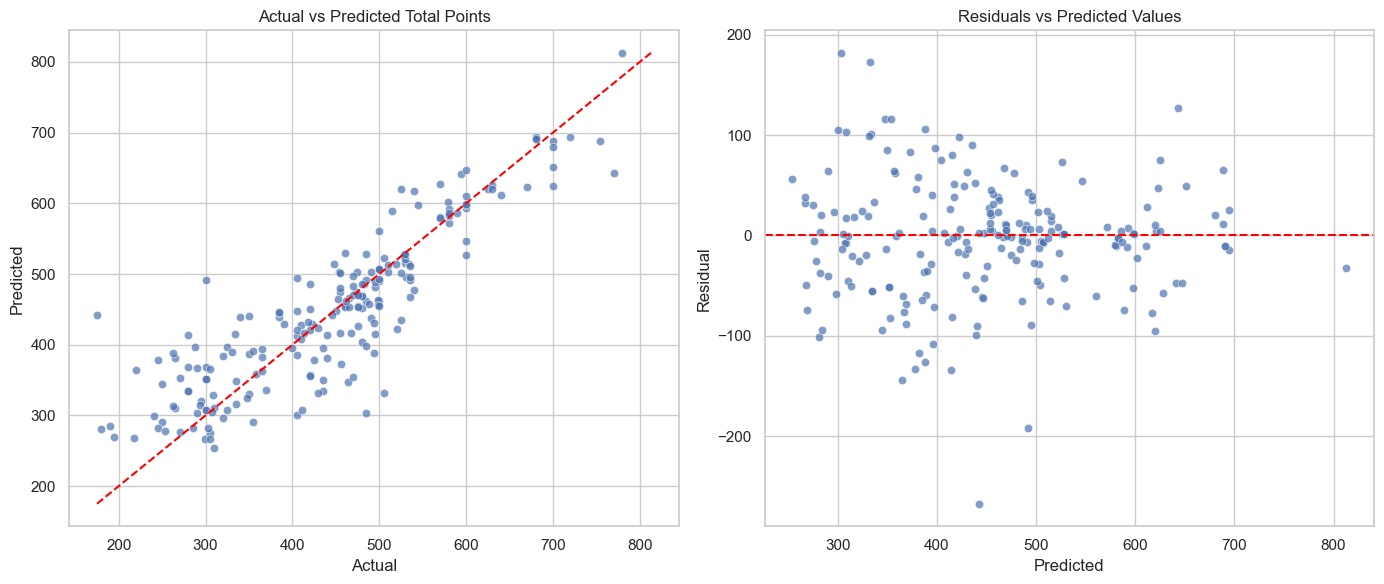

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=results, x="true_total_points", y="pred_total_points", alpha=0.7, ax=axes[0])
line_min = min(results["true_total_points"].min(), results["pred_total_points"].min())
line_max = max(results["true_total_points"].max(), results["pred_total_points"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="red")
axes[0].set_title("Actual vs Predicted Total Points")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

sns.scatterplot(data=results, x="pred_total_points", y="residual", alpha=0.7, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

plt.tight_layout()

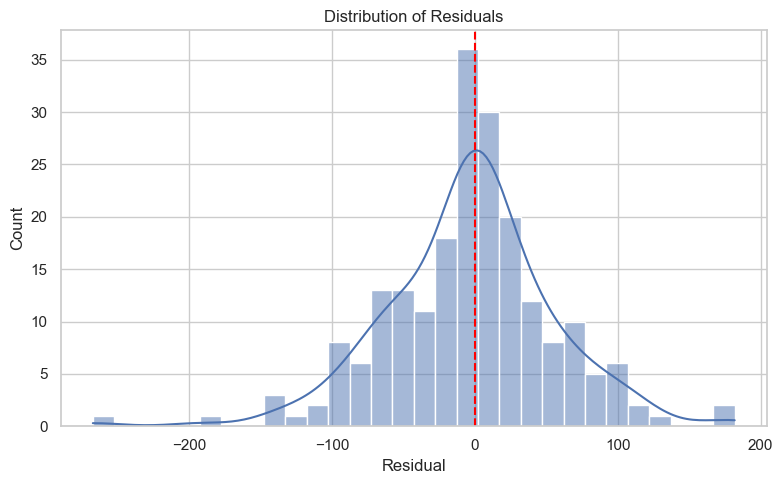

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(results["residual"], bins=30, kde=True)
plt.axvline(0, linestyle="--", color="red")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.tight_layout()

## Worst Tuned Model Predictions

In [10]:
worst_predictions = results.sort_values("abs_error", ascending=False).head(20)
worst_predictions[[
    "name",
    "status",
    "type_1",
    "type_2",
    "true_total_points",
    "pred_total_points",
    "residual",
    "abs_error",
]]

,name,status,type_1,type_2,true_total_points,pred_total_points,residual,abs_error
877,Wishiwashi Solo Form,Normal,Water,NaN,175,442.273590,-267.273590,267.273590
944,Meltan,Mythical,Steel,NaN,300,491.586884,-191.586884,191.586884
977,Flapple,Normal,Grass,Dragon,485,303.092834,181.907166,181.907166
962,Orbeetle,Normal,Bug,Psychic,505,332.007782,172.992218,172.992218
526,Happiny,Normal,Normal,NaN,220,364.267303,-144.267303,144.267303
644,Cottonee,Normal,Grass,Fairy,280,414.052246,-134.052246,134.052246
54,Zubat,Normal,Poison,Flying,245,377.810516,-132.810516,132.810516
462,Primal Groudon,Legendary,Ground,Fire,770,643.357788,126.642212,126.642212
208,Hoothoot,Normal,Normal,Flying,262,388.406738,-126.406738,126.406738
210,Ledyba,Normal,Bug,Flying,265,381.675751,-116.675751,116.675751


## Tuned Model Grouped Error Analysis

In [11]:
status_error_summary = (
    results.groupby("status")["abs_error"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
status_error_summary

,count,mean,median
status,,,
Mythical,4,51.458366,6.570404
Normal,184,43.352816,34.392044
Legendary,10,41.396503,29.330780
Sub Legendary,11,22.324230,10.750366


In [12]:
type_error_summary = (
    results.groupby("type_1")["abs_error"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
type_error_summary.head(10)

,count,mean,median
type_1,,,
Steel,8,71.822678,63.839600
Poison,8,61.146217,55.721146
Bug,15,52.711157,57.669739
Electric,6,52.539530,45.112183
Grass,28,50.284915,41.446289
Ghost,10,47.102762,31.927185
Normal,29,44.106386,30.987061
Water,24,40.616227,24.241608
Rock,9,38.939992,39.057465


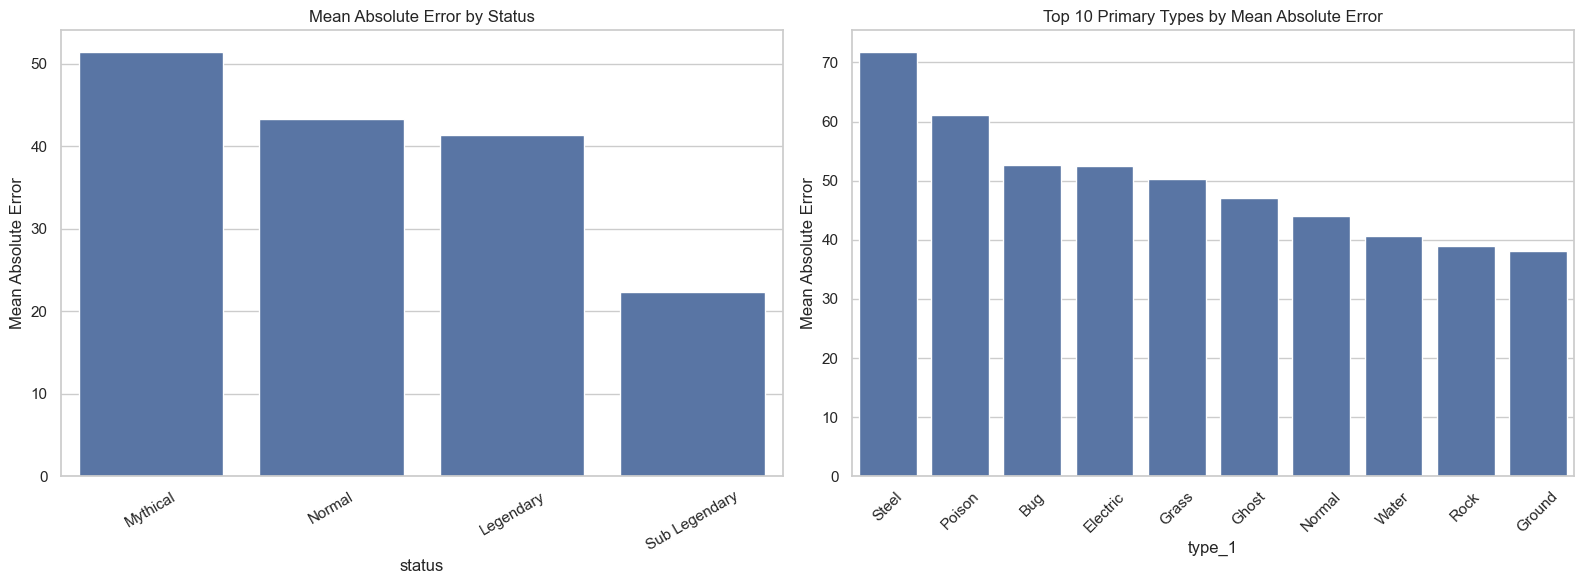

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_plot = status_error_summary.reset_index()
sns.barplot(data=status_plot, x="status", y="mean", ax=axes[0])
axes[0].set_title("Mean Absolute Error by Status")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Mean Absolute Error")

top_types = type_error_summary.head(10).reset_index()
sns.barplot(data=top_types, x="type_1", y="mean", ax=axes[1])
axes[1].set_title("Top 10 Primary Types by Mean Absolute Error")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Mean Absolute Error")

plt.tight_layout()

## Tuned Model Importance

In [14]:
feature_importance = (
    pd.Series(model.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
)
feature_importance.head(15)

status_normal           0.184093
log_height_m            0.111951
status_mythical         0.108573
is_mega                 0.057567
growth_rate_slow        0.055572
status_sub legendary    0.035349
type_1_electric         0.024135
log_weight_kg           0.023840
is_form                 0.018316
type_2_dragon           0.016890
growth_rate_fast        0.015893
type_2_ghost            0.015743
type_1_fighting         0.014734
type_2_rock             0.014182
type_2_steel            0.013990
dtype: float32

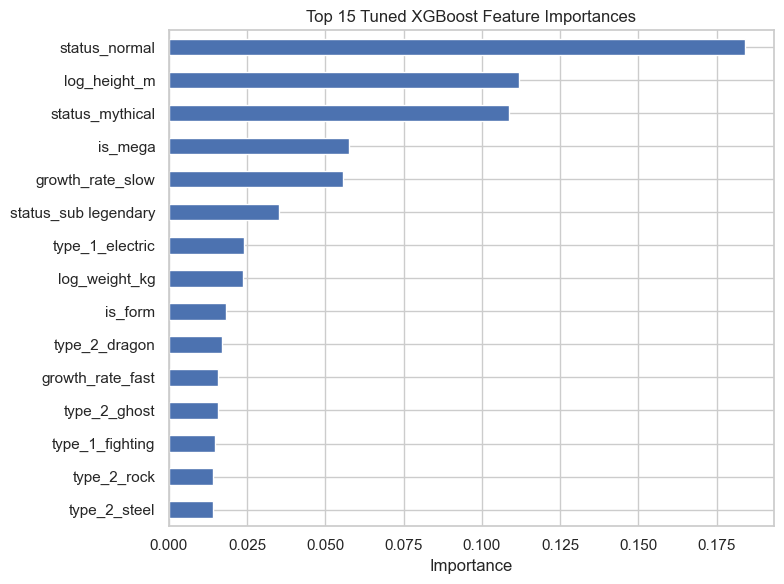

In [15]:
feature_importance.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()